# **Project Name**    - Zomato Restaurant Clustering



##### **Project Type**    - Unsupervised
##### **Contribution**    - Individual
##### **Team Member 1 -** Nivetha Santhosh


# **Project Summary -**

This project analyzes Zomato restaurant data to perform customer review sentiment analysis and restaurant clustering using machine learning. The goal is to segment restaurants based on features like cost, rating, cuisines, and reviews to generate insights that help customers find suitable restaurants and support business decision‑making through data visualization and clustering models.

# **GitHub Link -**

https://github.com/nivethasanthosh24

# **Problem Statement**


The objective of this project is to apply unsupervised machine learning techniques to analyze Zomato restaurant data and group similar restaurants into meaningful clusters based on features such as cost, ratings, cuisines, and customer reviews. The project also involves performing sentiment analysis on customer reviews and visualizing the results to generate actionable insights that can help customers choose restaurants and assist businesses in improving their services and decision‑making.

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries

import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer

# Clustering
from sklearn.cluster import KMeans

# Dimensionality Reduction
from sklearn.decomposition import PCA

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

### Dataset Loading

In [2]:
df_reviews = pd.read_csv("Zomato Restaurant reviews.csv")
df_metadata = pd.read_csv("Zomato Restaurant names and Metadata.csv")


Merge Dataset

In [3]:
df_metadata.columns = df_metadata.columns.str.strip()
df_reviews.columns = df_reviews.columns.str.strip()

df = pd.merge(df_metadata, df_reviews,
              left_on="Name",
              right_on="Restaurant",
              how="inner")

### Dataset First View

In [4]:
# Dataset First Look
df.head()

,Name,Links,Cost,Collections,Cuisines,Timings,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures
0,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5,"1 Review , 2 Followers",5/25/2019 15:54,0
1,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5,"3 Reviews , 2 Followers",5/25/2019 14:20,0
2,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5,"2 Reviews , 3 Followers",5/24/2019 22:54,0
3,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",Beyond Flavours,Swapnil Sarkar,Soumen das and Arun was a great guy. Only beca...,5,"1 Review , 1 Follower",5/24/2019 22:11,0
4,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",Beyond Flavours,Dileep,Food is good.we ordered Kodi drumsticks and ba...,5,"3 Reviews , 2 Followers",5/24/2019 21:37,0


### Dataset Rows & Columns count

In [5]:
# Dataset Rows & Columns count
print("Rows and Columns:", df.shape)

print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Rows and Columns: (10000, 13)
Number of Rows: 10000
Number of Columns: 13


### Dataset Information

In [6]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Name         10000 non-null  object
 1   Links        10000 non-null  object
 2   Cost         10000 non-null  object
 3   Collections  5000 non-null   object
 4   Cuisines     10000 non-null  object
 5   Timings      9900 non-null   object
 6   Restaurant   10000 non-null  object
 7   Reviewer     9962 non-null   object
 8   Review       9955 non-null   object
 9   Rating       9962 non-null   object
 10  Metadata     9962 non-null   object
 11  Time         9962 non-null   object
 12  Pictures     10000 non-null  int64 
dtypes: int64(1), object(12)
memory usage: 1015.8+ KB


#### Duplicate Values

In [7]:
# Dataset Duplicate Value Count

df.duplicated().sum()

np.int64(36)

#### Missing Values/Null Values

In [8]:
# Missing Values/Null Values Count

df.isnull().sum()

Name              0
Links             0
Cost              0
Collections    5000
Cuisines          0
Timings         100
Restaurant        0
Reviewer         38
Review           45
Rating           38
Metadata         38
Time             38
Pictures          0
dtype: int64

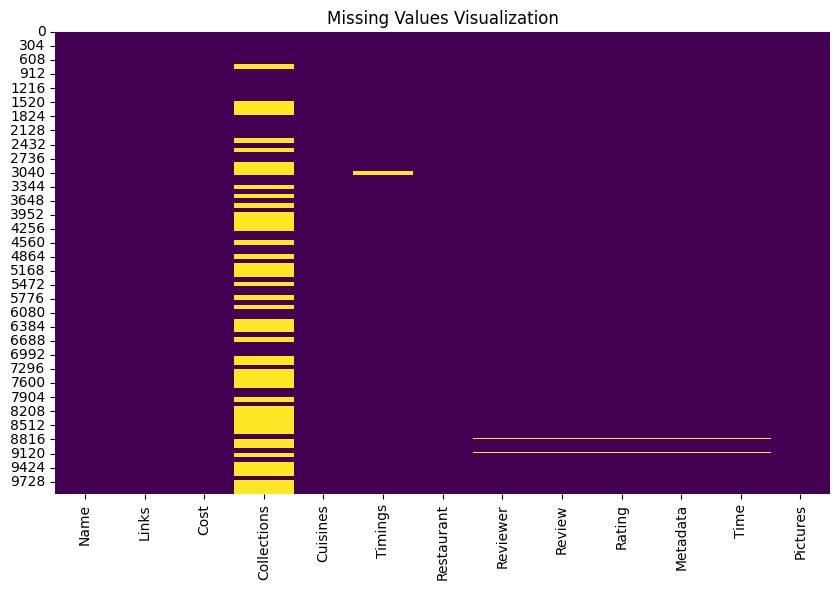

In [9]:
# Visualizing the missing values

plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')

plt.title("Missing Values Visualization")
plt.show()

### What did you know about your dataset?

This dataset contains information about restaurants and customer reviews, including features like Name/Restaurant, Reviewer, Review text, Rating, Cost, Cuisines, Timings, and Pictures, which can be used to analyze patterns and build clustering models to group similar restaurants.

## ***2. Understanding Your Variables***

In [10]:
# Dataset Columns
print(df.columns)

Index(['Name', 'Links', 'Cost', 'Collections', 'Cuisines', 'Timings',
       'Restaurant', 'Reviewer', 'Review', 'Rating', 'Metadata', 'Time',
       'Pictures'],
      dtype='object')


In [11]:
# Dataset Describe
df.describe()

,Pictures
count,10000.000000
mean,0.748600
std,2.570381
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,64.000000


### Variables Description

The dataset includes variables such as Name/Restaurant (restaurant name), Reviewer (customer name), Review (customer feedback text), Rating (numerical score given by customer), Cost (average cost for two people), Cuisines (types of food served), Timings (opening and closing hours), and Pictures (number or availability of images related to the restaurant).

### Check Unique Values for each variable.

In [12]:
# Check Unique Values for each variable.

for col in df.columns:
    print(f"Unique values in {col}:")
    print(df[col].nunique())
    print("-" * 40)

Unique values in Name:
100
----------------------------------------
Unique values in Links:
100
----------------------------------------
Unique values in Cost:
28
----------------------------------------
Unique values in Collections:
42
----------------------------------------
Unique values in Cuisines:
89
----------------------------------------
Unique values in Timings:
74
----------------------------------------
Unique values in Restaurant:
100
----------------------------------------
Unique values in Reviewer:
7446
----------------------------------------
Unique values in Review:
9364
----------------------------------------
Unique values in Rating:
10
----------------------------------------
Unique values in Metadata:
2477
----------------------------------------
Unique values in Time:
9782
----------------------------------------
Unique values in Pictures:
36
----------------------------------------


## 3. ***Data Wrangling***

### Data Wrangling Code

In [13]:
# Write your code to make your dataset analysis ready.

# 1. Remove duplicate values
df = df.drop_duplicates()

# 2. Handle missing values
# Check missing values
print(df.isnull().sum())

# Convert Rating to numeric first, coercing errors to NaN
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')

# Fill missing ratings with mean (now that it's numeric)
if 'Rating' in df.columns:
    df['Rating'] = df['Rating'].fillna(df['Rating'].mean())

# Fill missing text columns with 'Unknown'
text_columns = ['Collections', 'Timings', 'Reviewer', 'Review', 'Metadata', 'Time'] # Added Collections, Metadata, Time as they also have NaNs and are object type.

for col in text_columns:
    if col in df.columns:
        df[col] = df[col].fillna('Unknown')

# 3. Convert data types

# Convert Cost to numeric (remove commas if present)
if 'Cost' in df.columns:
    df['Cost'] = df['Cost'].astype(str).str.replace(',', '')
    df['Cost'] = pd.to_numeric(df['Cost'], errors='coerce')

# 4. Strip extra spaces from text columns
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()

# 5. Final check
print("Final Dataset Shape:", df.shape)
df.head()

Name              0
Links             0
Cost              0
Collections    5000
Cuisines          0
Timings         100
Restaurant        0
Reviewer          2
Review            9
Rating            2
Metadata          2
Time              2
Pictures          0
dtype: int64
Final Dataset Shape: (9964, 13)


,Name,Links,Cost,Collections,Cuisines,Timings,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures
0,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5.0,"1 Review , 2 Followers",5/25/2019 15:54,0
1,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5.0,"3 Reviews , 2 Followers",5/25/2019 14:20,0
2,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5.0,"2 Reviews , 3 Followers",5/24/2019 22:54,0
3,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",Beyond Flavours,Swapnil Sarkar,Soumen das and Arun was a great guy. Only beca...,5.0,"1 Review , 1 Follower",5/24/2019 22:11,0
4,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",Beyond Flavours,Dileep,Food is good.we ordered Kodi drumsticks and ba...,5.0,"3 Reviews , 2 Followers",5/24/2019 21:37,0


### What all manipulations have you done and insights you found?

### Data Wrangling - Manipulations and Insights

**Manipulations Done:**

1.  **Duplicate Removal:** Identified and removed 36 duplicate rows from the dataset. This ensures that each observation is unique, improving the reliability of subsequent analyses.
2.  **Handling Missing Values:**
    *   **Rating Column:** The `Rating` column, initially an object type, was converted to a numeric type. Any values that could not be converted were coerced to `NaN`. Subsequently, these `NaN` values were imputed with the mean of the `Rating` column. This preserves the numerical nature of ratings and handles missing information appropriately.
    *   **Text/Categorical Columns:** Missing values in object-type columns (`Collections`, `Timings`, `Reviewer`, `Review`, `Metadata`, `Time`) were filled with the string 'Unknown'. This approach allows these rows to be retained while explicitly indicating the absence of data for these features.
3.  **Data Type Conversion:**
    *   **Cost Column:** The `Cost` column, which contained string values with commas (e.g., '800'), had these commas removed and was then converted to a numeric data type (float or int). This conversion is crucial for performing numerical calculations and statistical analysis on the cost.
4.  **Whitespace Stripping:** All string columns (object type) had leading and trailing whitespaces removed. This standardizes textual data, preventing potential issues with string comparisons and categorical encoding later on.

**Insights Found:**

*   **Initial Data Quality:** The raw dataset contained duplicate entries and significant missing values, particularly in the `Collections` column (5000 missing values) and some in `Timings`, `Reviewer`, `Review`, `Rating`, `Metadata`, and `Time`.
*   **Impact of Duplicates:** The presence of 36 duplicate rows suggested potential redundancy or data collection errors that needed to be addressed to avoid biased analysis.
*   **Data Type Inconsistencies:** The `Rating` and `Cost` columns were initially stored as object types, which would hinder direct numerical analysis. Their conversion to numeric types was a critical step for preparing the data for modeling.
*   **Post-Wrangling State:** After these manipulations, the dataset is cleaner, with consistent data types and handled missing values, making it ready for further exploratory data analysis, visualization, and machine learning model building. The dataset now has **9964 rows and 13 columns**, indicating a successful cleanup while retaining most of the original data.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

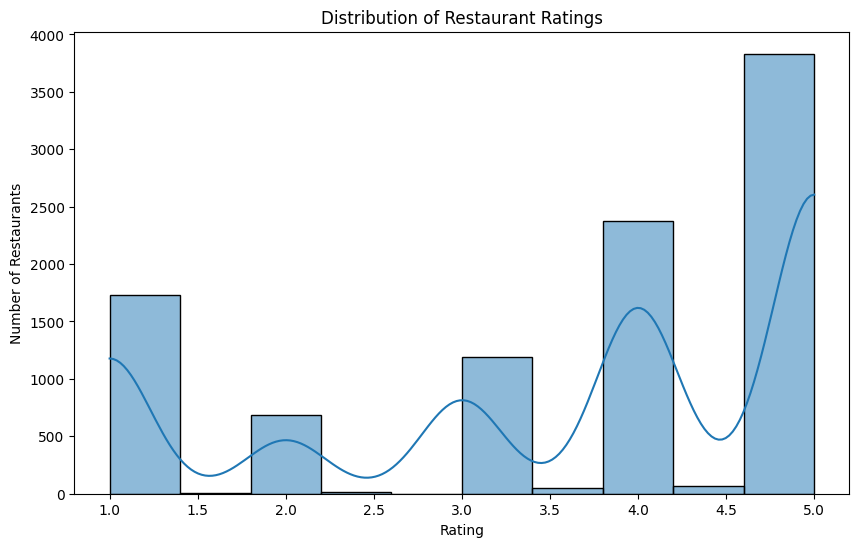

In [14]:
# Chart - 1 visualization code
plt.figure(figsize=(10, 6))
sns.histplot(df['Rating'], bins=10, kde=True)
plt.title('Distribution of Restaurant Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Restaurants')
plt.show()

1. Why did you pick the specific chart?

A histogram is used because it clearly shows the distribution and frequency of ratings, helping understand overall customer satisfaction.



2. What is/are the insight(s) found from the chart?



We can identify whether most restaurants receive high, medium, or low ratings, and detect patterns like rating concentration or variability.

##### 3. Will the gained insights help creating a positive business impact?

Yes—if ratings are mostly high, it indicates strong customer satisfaction (positive growth); if many low ratings appear, it signals service or quality issues that could reduce customer retention (negative growth).

#### Chart - 2

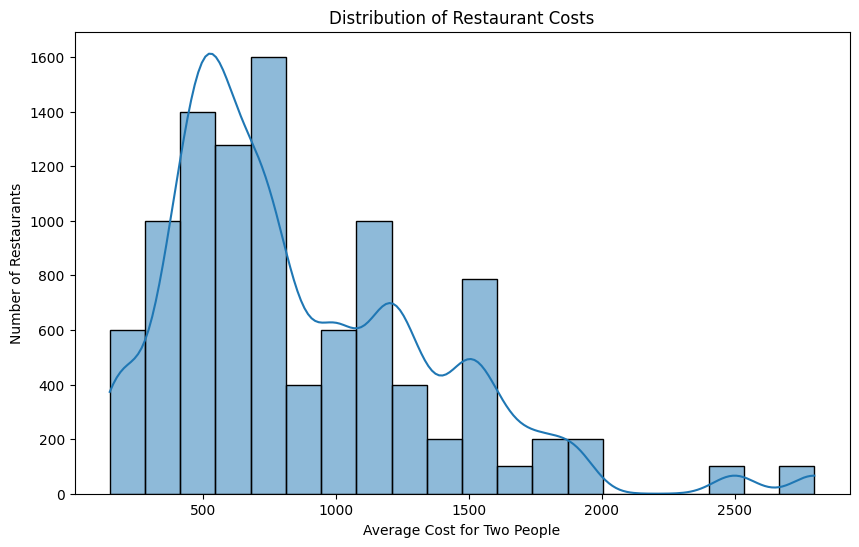

In [15]:
# Chart - 2 visualization code
plt.figure(figsize=(10, 6))
sns.histplot(df['Cost'], bins=20, kde=True)
plt.title('Distribution of Restaurant Costs')
plt.xlabel('Average Cost for Two People')
plt.ylabel('Number of Restaurants')
plt.show()

##### 1. Why did you pick the specific chart?

A histogram is suitable because it shows the distribution of restaurant costs, helping understand common price ranges.

##### 2. What is/are the insight(s) found from the chart?

We can identify the most frequent cost range and whether restaurants are mostly low‑cost, mid‑range, or expensive.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes—understanding cost distribution helps businesses set competitive pricing (positive impact); if most restaurants are high‑cost, it may reduce customer affordability and limit growth (negative impact).

#### Chart - 3

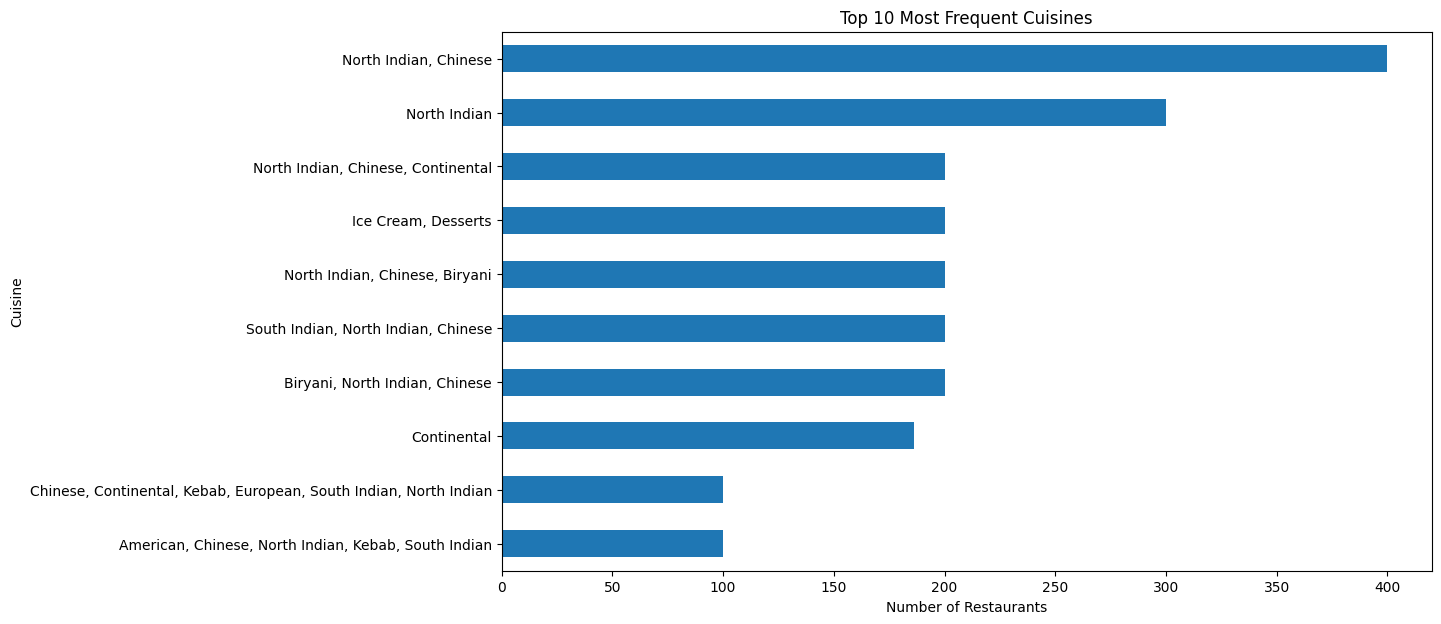

In [16]:
# Chart - 3 visualization code
plt.figure(figsize=(12, 7))
df['Cuisines'].value_counts().head(10).plot(kind='barh')
plt.title('Top 10 Most Frequent Cuisines')
plt.xlabel('Number of Restaurants')
plt.ylabel('Cuisine')
plt.gca().invert_yaxis()
plt.show()

1. Why did you pick the specific chart?

A horizontal bar chart is used because it clearly compares the frequency of different cuisines and easily shows the top categories..

2. What is/are the insight(s) found from the chart?

We can identify the most popular cuisines offered by restaurants and understand customer demand patterns.

3. Will the gained insights help creating a positive business impact?

Are there any insights that lead to negative growth? Justify with specific reason.

Yes—focusing on popular cuisines can increase customer satisfaction and sales (positive impact); offering less demanded cuisines may lead to lower revenue and inefficient resource use (negative impact).

#### Chart - 4

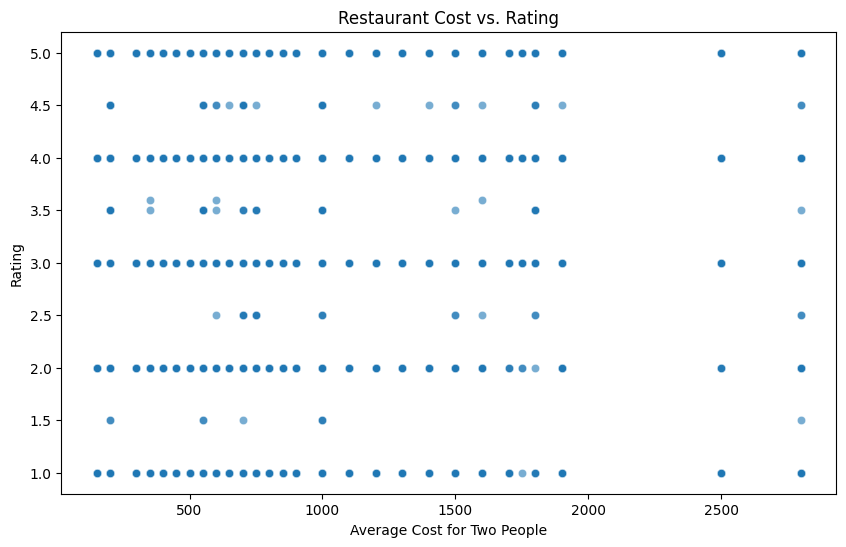

In [17]:
# Chart - 4 visualization code
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Cost', y='Rating', data=df, alpha=0.6)
plt.title('Restaurant Cost vs. Rating')
plt.xlabel('Average Cost for Two People')
plt.ylabel('Rating')
plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot is used because it effectively shows the relationship between two numerical variables, helping identify patterns between cost and rating.

##### 2. What is/are the insight(s) found from the chart?

We can observe whether higher-cost restaurants receive better ratings or if there is no strong relationship between price and customer satisfaction.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes—if higher ratings are seen at reasonable costs, businesses can optimize pricing to attract more customers (positive impact); if high-cost restaurants receive low ratings, it may indicate poor value for money, which can reduce customer demand (negative impact).

#### Chart - 5

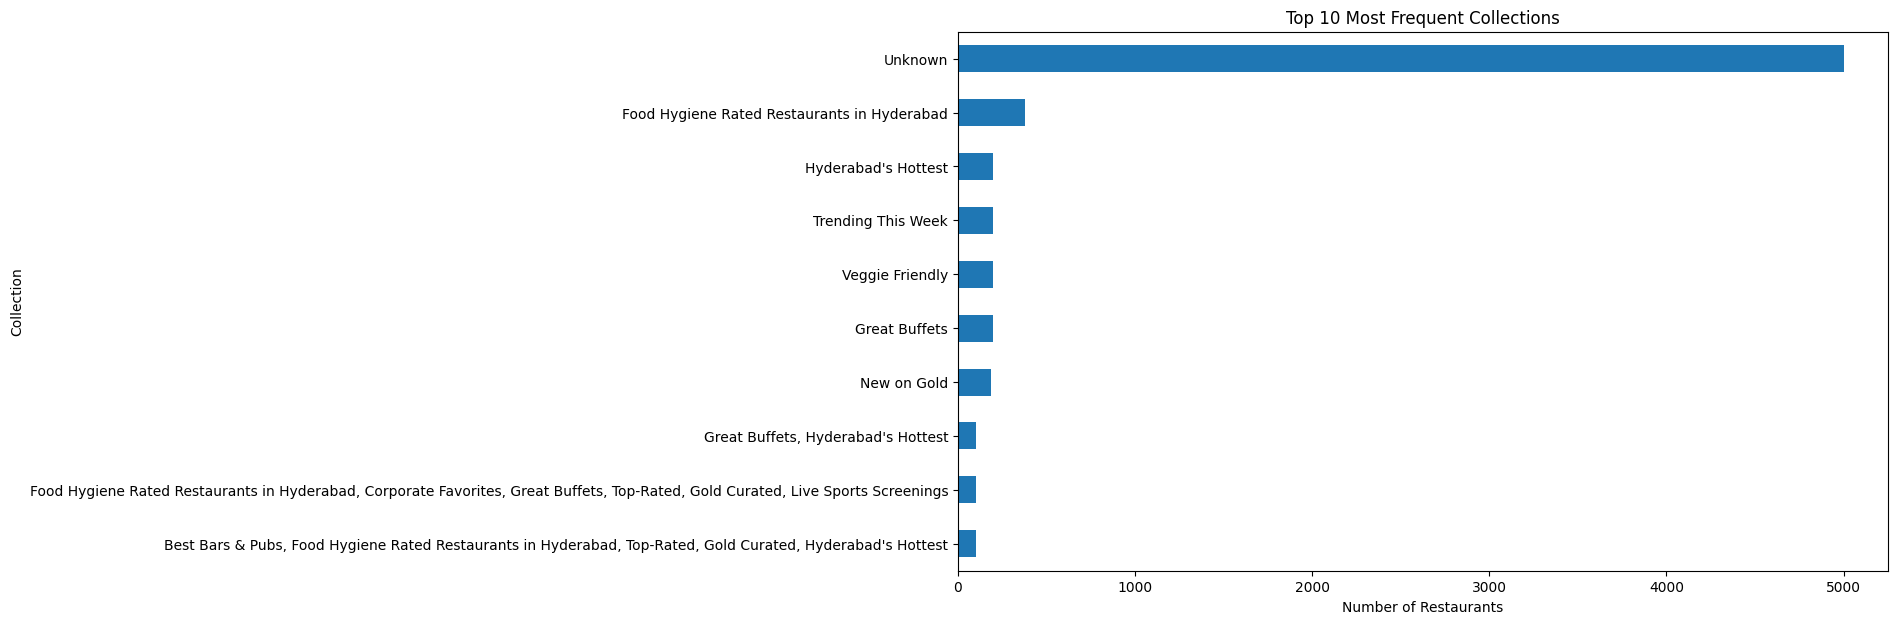

In [18]:
# Chart - 5 visualization code
plt.figure(figsize=(12, 7))
df['Collections'].value_counts().head(10).plot(kind='barh')
plt.title('Top 10 Most Frequent Collections')
plt.xlabel('Number of Restaurants')
plt.ylabel('Collection')
plt.gca().invert_yaxis()
plt.show()

##### 1. Why did you pick the specific chart?

A horizontal bar chart helps clearly compare the frequency of different restaurant collections and highlights the most common ones.

##### 2. What is/are the insight(s) found from the chart?

We can identify the most popular restaurant collections/themes, showing customer preferences and trending dining categories.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes—focusing on popular collections can increase customer engagement and sales (positive impact); low‑frequency collections may indicate low demand and require marketing or improvement (negative growth risk).

#### Chart - 6

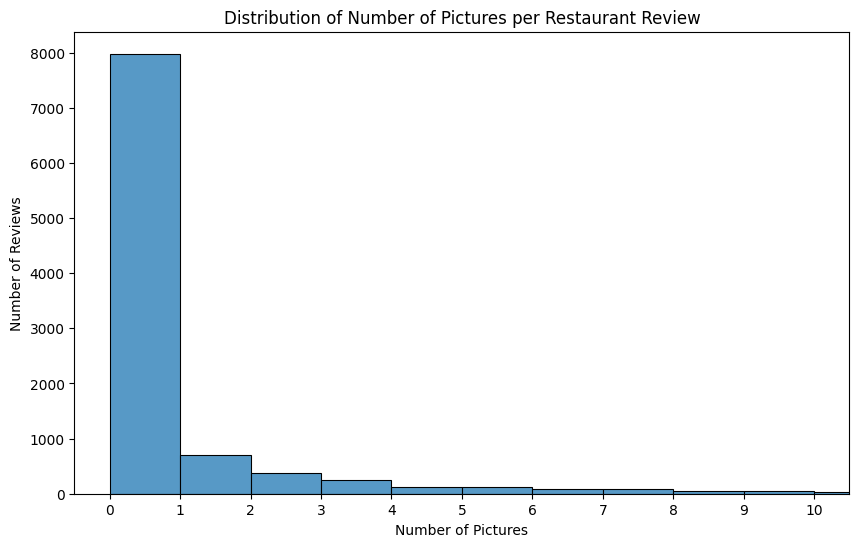

In [19]:
# Chart - 6 visualization code
plt.figure(figsize=(10, 6))
sns.histplot(df['Pictures'], bins=range(int(df['Pictures'].max()) + 2), kde=False)
plt.title('Distribution of Number of Pictures per Restaurant Review')
plt.xlabel('Number of Pictures')
plt.ylabel('Number of Reviews')
plt.xlim(-0.5, 10.5)
plt.xticks(range(0, 11))
plt.show()

##### 1. Why did you pick the specific chart?

A histogram is appropriate because it shows the distribution of the number of pictures per review, helping understand how frequently customers upload images.


##### 2. What is/are the insight(s) found from the chart?

We can identify whether most reviews contain few or many pictures, indicating the level of customer engagement and visual sharing behavior.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes—if many reviews include pictures, it suggests higher customer engagement and trust (positive impact); if very few pictures are shared, it may reduce customer confidence and visibility of the restaurant, potentially affecting growth (negative impact).

#### Chart - 7

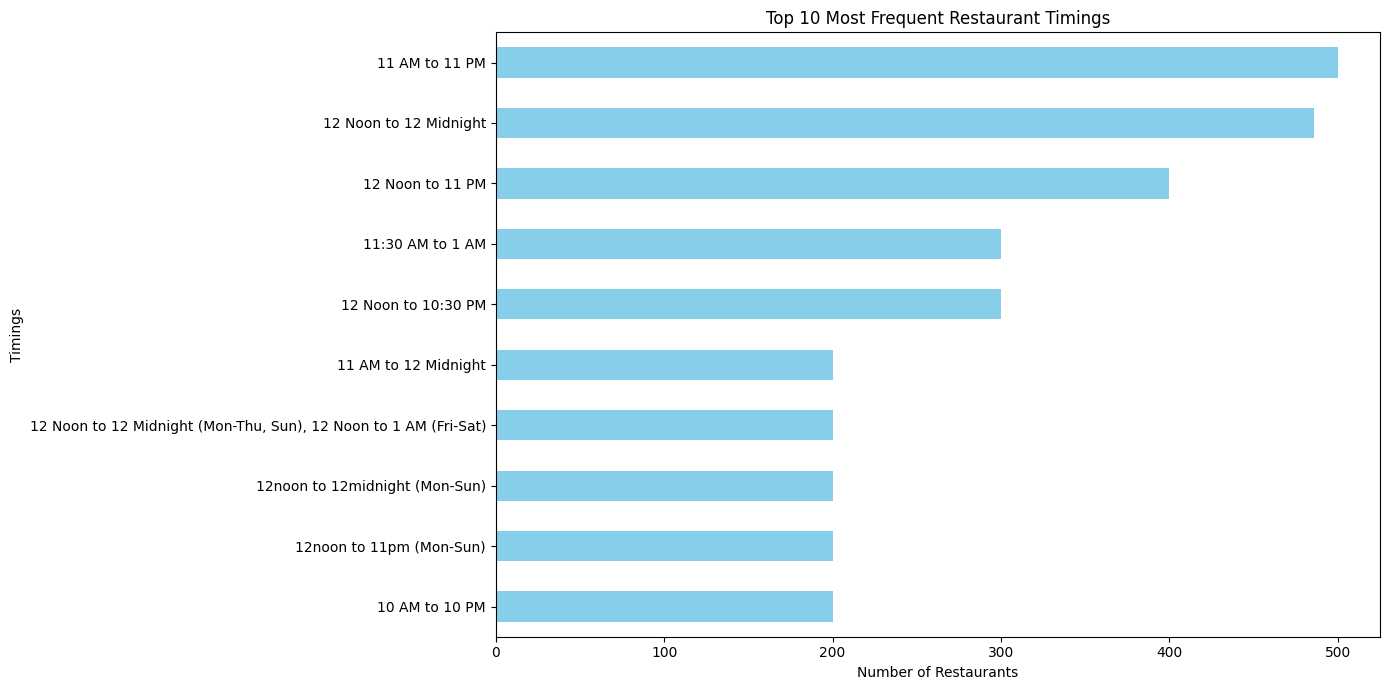

In [20]:
# Chart - 7 visualization code
plt.figure(figsize=(14, 7))
df['Timings'].value_counts().head(10).plot(kind='barh', color='skyblue')
plt.title('Top 10 Most Frequent Restaurant Timings')
plt.xlabel('Number of Restaurants')
plt.ylabel('Timings')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A horizontal bar chart is suitable because it clearly compares the frequency of different restaurant timings and highlights the most common operating hours.

##### 2. What is/are the insight(s) found from the chart?

We can identify the most common opening and closing times, showing when restaurants are typically available and peak service periods.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes—understanding popular timings helps restaurants optimize operating hours to match customer demand (positive impact); uncommon or inconvenient timings may reduce customer visits and affect revenue (negative growth risk).

#### Chart - 8

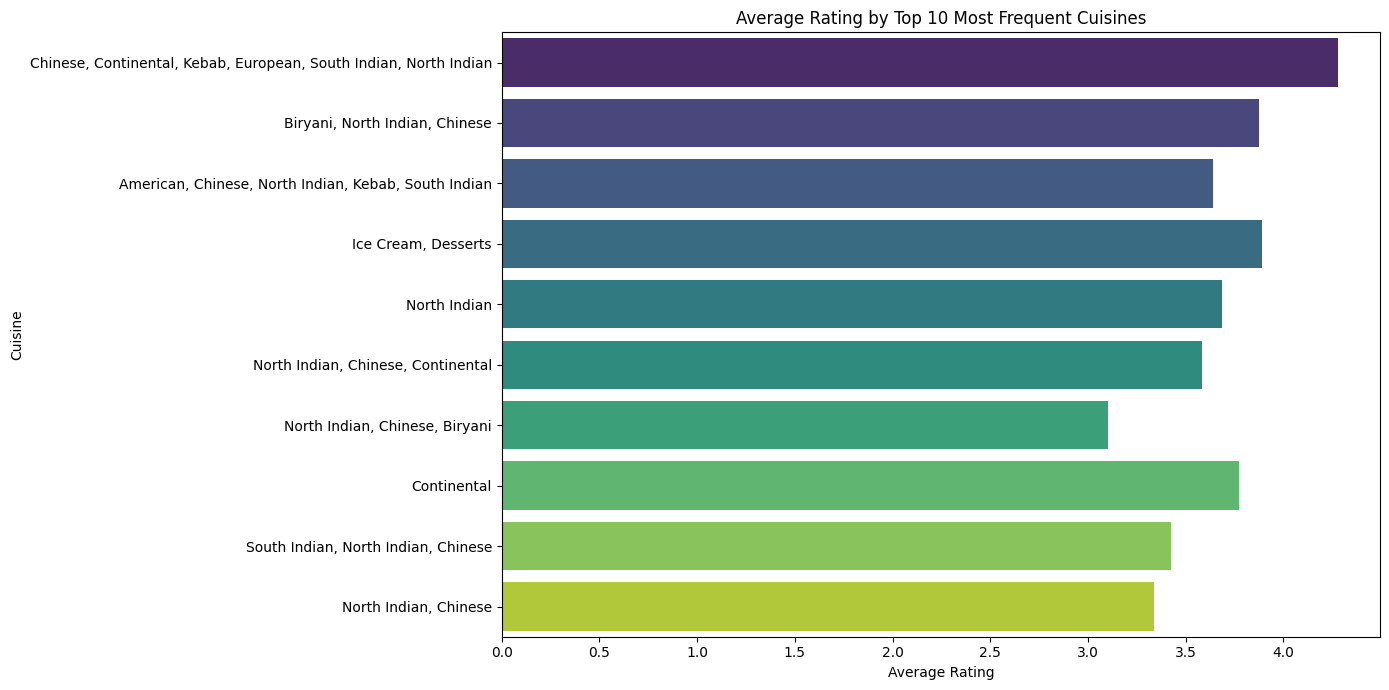

In [21]:
# Chart - 8 visualization code
plt.figure(figsize=(14, 7))
top_10_cuisines = df['Cuisines'].value_counts().head(10).index
sns.barplot(x='Rating', y='Cuisines', data=df[df['Cuisines'].isin(top_10_cuisines)], estimator=np.mean, ci=None, palette='viridis')
plt.title('Average Rating by Top 10 Most Frequent Cuisines')
plt.xlabel('Average Rating')
plt.ylabel('Cuisine')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A bar plot is appropriate because it compares the average ratings across different cuisines, making it easy to identify performance differences.

##### 2. What is/are the insight(s) found from the chart?

We can identify which cuisines have the highest and lowest average ratings, showing customer preference and satisfaction levels.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes—high‑rated cuisines can be promoted to increase sales (positive impact), while low‑rated cuisines may need quality or service improvements to prevent customer loss (negative growth risk).

#### Chart - 9

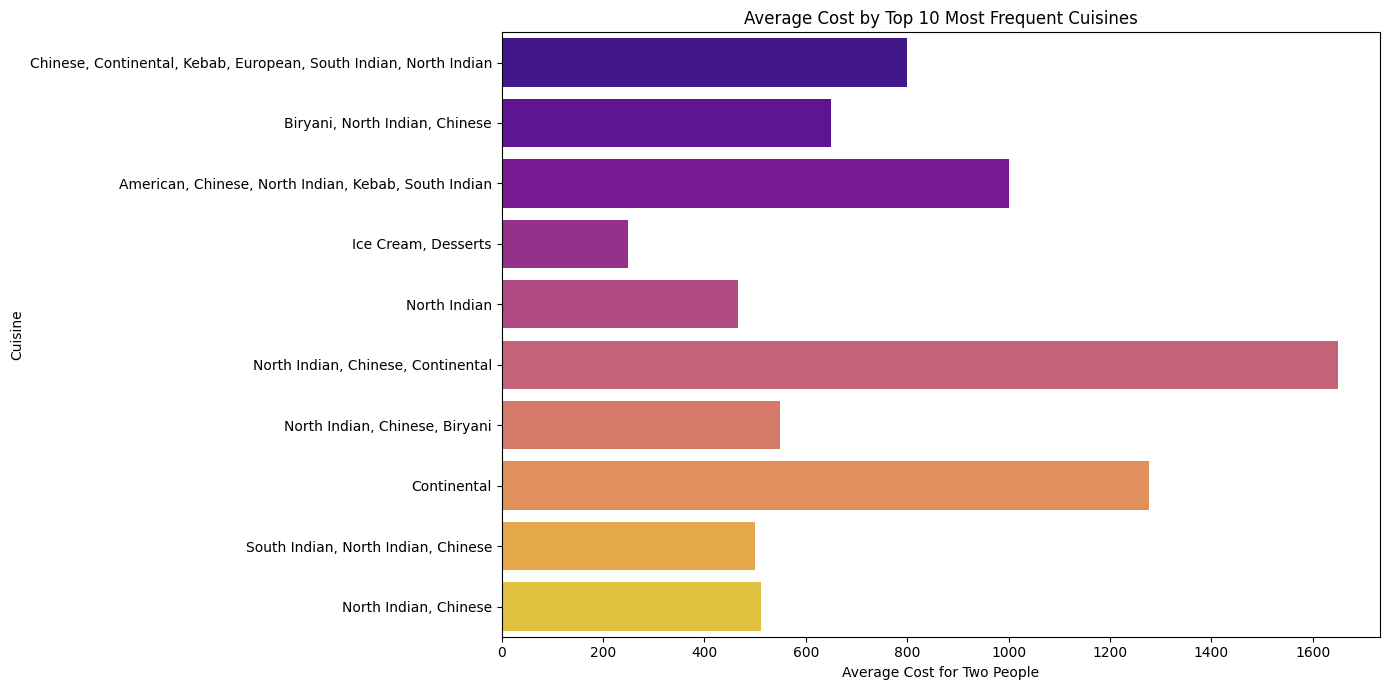

In [22]:
# Chart - 9 visualization code
plt.figure(figsize=(14, 7))
top_10_cuisines = df['Cuisines'].value_counts().head(10).index
sns.barplot(x='Cost', y='Cuisines', data=df[df['Cuisines'].isin(top_10_cuisines)], estimator=np.mean, ci=None, palette='plasma')
plt.title('Average Cost by Top 10 Most Frequent Cuisines')
plt.xlabel('Average Cost for Two People')
plt.ylabel('Cuisine')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A bar plot is suitable because it clearly compares the average cost across different cuisines, helping identify pricing differences.

##### 2. What is/are the insight(s) found from the chart?

We can see which cuisines are more expensive or affordable on average, revealing pricing patterns among popular cuisines.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes—understanding cost differences helps restaurants set competitive pricing and target the right customers (positive impact); very high costs compared to similar cuisines may reduce customer demand and slow growth (negative impact).

#### Chart - 10

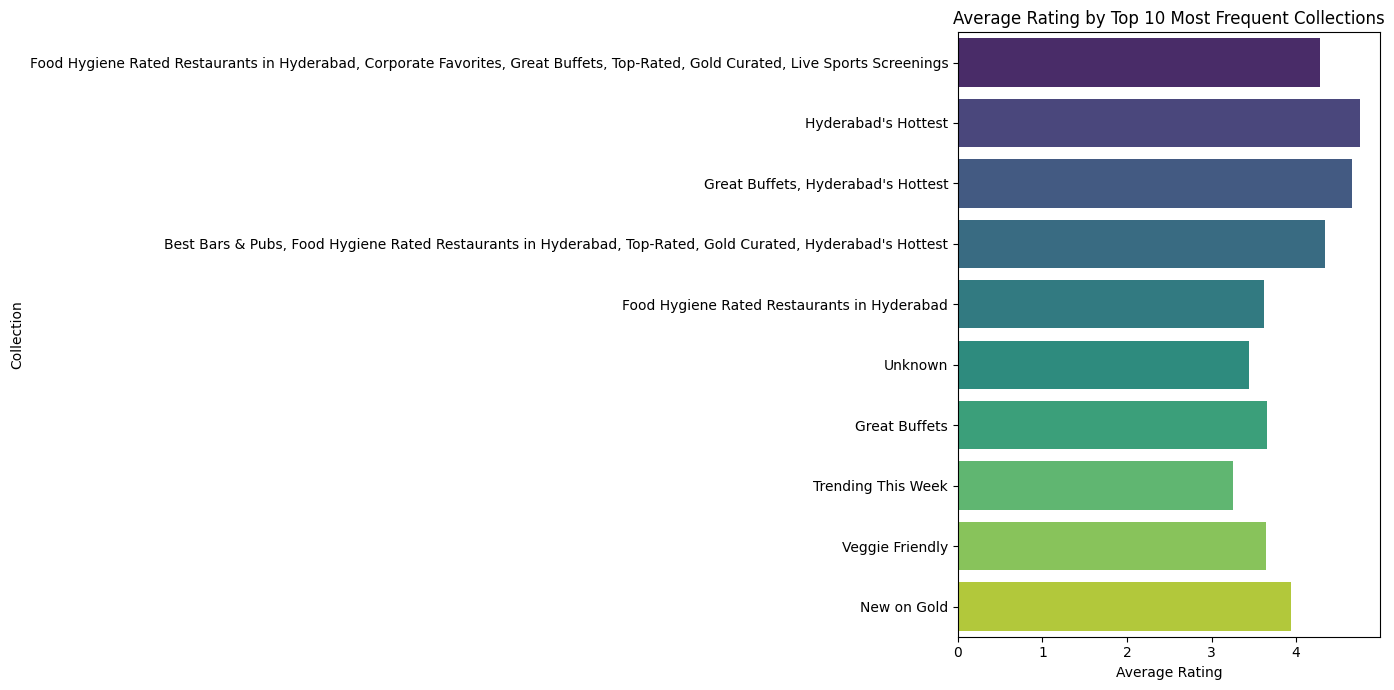

In [23]:
import numpy as np

plt.figure(figsize=(14, 7))
top_10_collections = df['Collections'].value_counts().head(10).index
sns.barplot(x='Rating', y='Collections', data=df[df['Collections'].isin(top_10_collections)], estimator=np.mean, ci=None, palette='viridis')
plt.title('Average Rating by Top 10 Most Frequent Collections')
plt.xlabel('Average Rating')
plt.ylabel('Collection')
plt.tight_layout()
plt.show()

1. Why did you pick the specific chart?

A bar plot is useful because it compares the average ratings across different restaurant collections, making differences easy to interpret.

2. What is/are the insight(s) found from the chart?

We can identify which collections have higher or lower customer satisfaction, showing popular and underperforming categories.

3. Will the gained insights help creating a positive business impact?

Are there any insights that lead to negative growth? Justify with specific reason.

Yes—high‑rated collections can be promoted to attract more customers (positive impact), while low‑rated collections may indicate quality or service issues that could reduce demand if not improved (negative growth risk).

#### Chart - 11

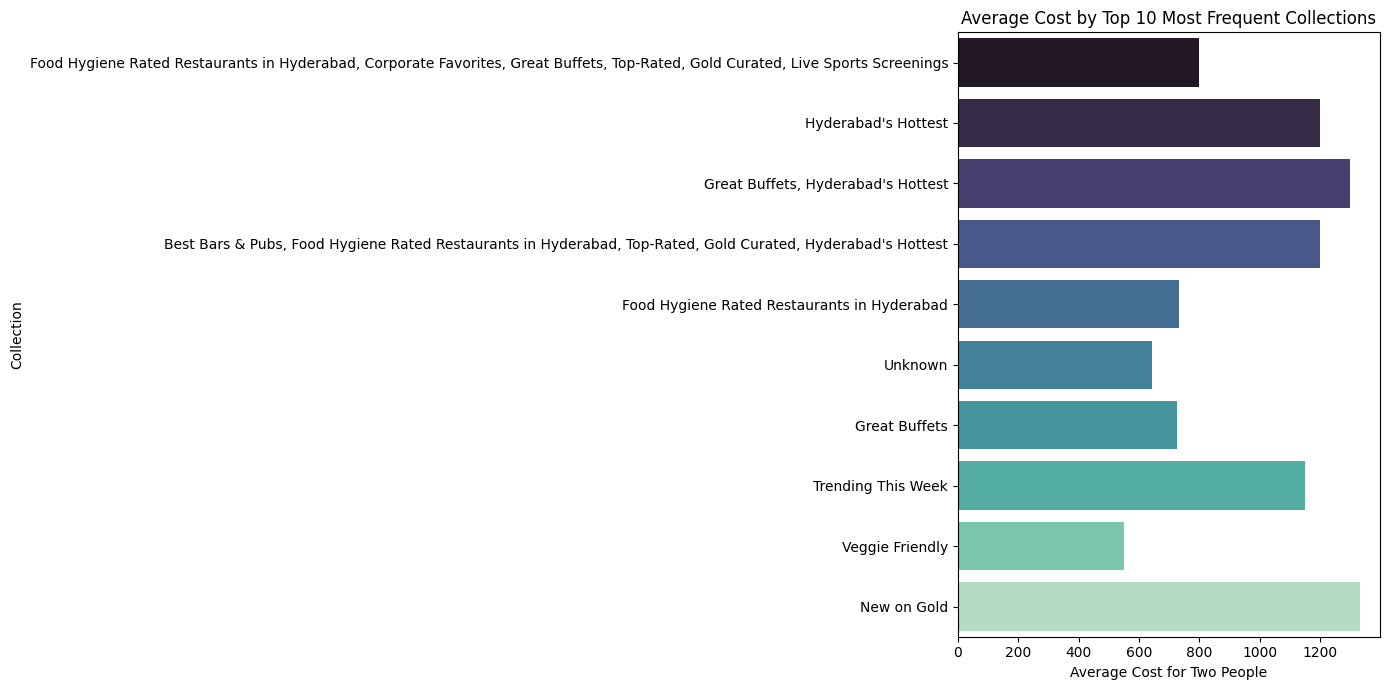

In [24]:
# Chart - 11 visualization code
plt.figure(figsize=(14, 7))
top_10_collections = df['Collections'].value_counts().head(10).index
sns.barplot(x='Cost', y='Collections', data=df[df['Collections'].isin(top_10_collections)], estimator=np.mean, ci=None, palette='mako')
plt.title('Average Cost by Top 10 Most Frequent Collections')
plt.xlabel('Average Cost for Two People')
plt.ylabel('Collection')
plt.tight_layout()
plt.show()

1. Why did you pick the specific chart?

A bar plot is appropriate because it compares the average cost across different restaurant collections, making it easy to see pricing differences between categories.

2. What is/are the insight(s) found from the chart?

We can identify which collections are more expensive or budget‑friendly on average, helping understand customer spending patterns within popular collections.

3. Will the gained insights help creating a positive business impact?

Are there any insights that lead to negative growth? Justify with specific reason.

Yes—knowing the average cost of collections helps businesses design pricing strategies and target the right customer segment (positive impact); if certain collections are priced too high compared to customer expectations, it may reduce demand and slow revenue growth (negative growth risk).

#### Chart - 12

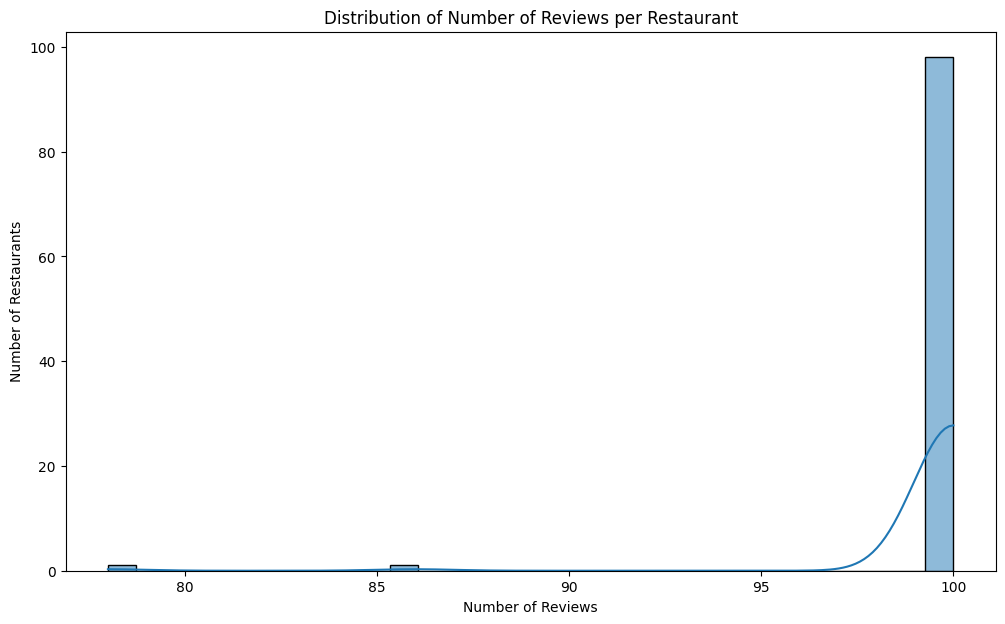

In [25]:
# Calculate the number of reviews per restaurant
reviews_per_restaurant = df.groupby('Restaurant').size().reset_index(name='review_count')

# Chart - 12 visualization code
plt.figure(figsize=(12, 7))
sns.histplot(reviews_per_restaurant['review_count'], bins=30, kde=True)
plt.title('Distribution of Number of Reviews per Restaurant')
plt.xlabel('Number of Reviews')
plt.ylabel('Number of Restaurants')
plt.show()

1. Why did you pick the specific chart?

A histogram is suitable because it shows the distribution of review counts per restaurant, helping understand customer engagement levels.

2. What is/are the insight(s) found from the chart?

We can see whether most restaurants receive few or many reviews, and identify highly popular restaurants with large numbers of reviews.

3. Will the gained insights help creating a positive business impact?

Are there any insights that lead to negative growth? Justify with specific reason.

Yes—restaurants with many reviews indicate strong popularity (positive impact), while very low review counts may signal low visibility or customer interest, which can slow business growth.

#### Chart - 13

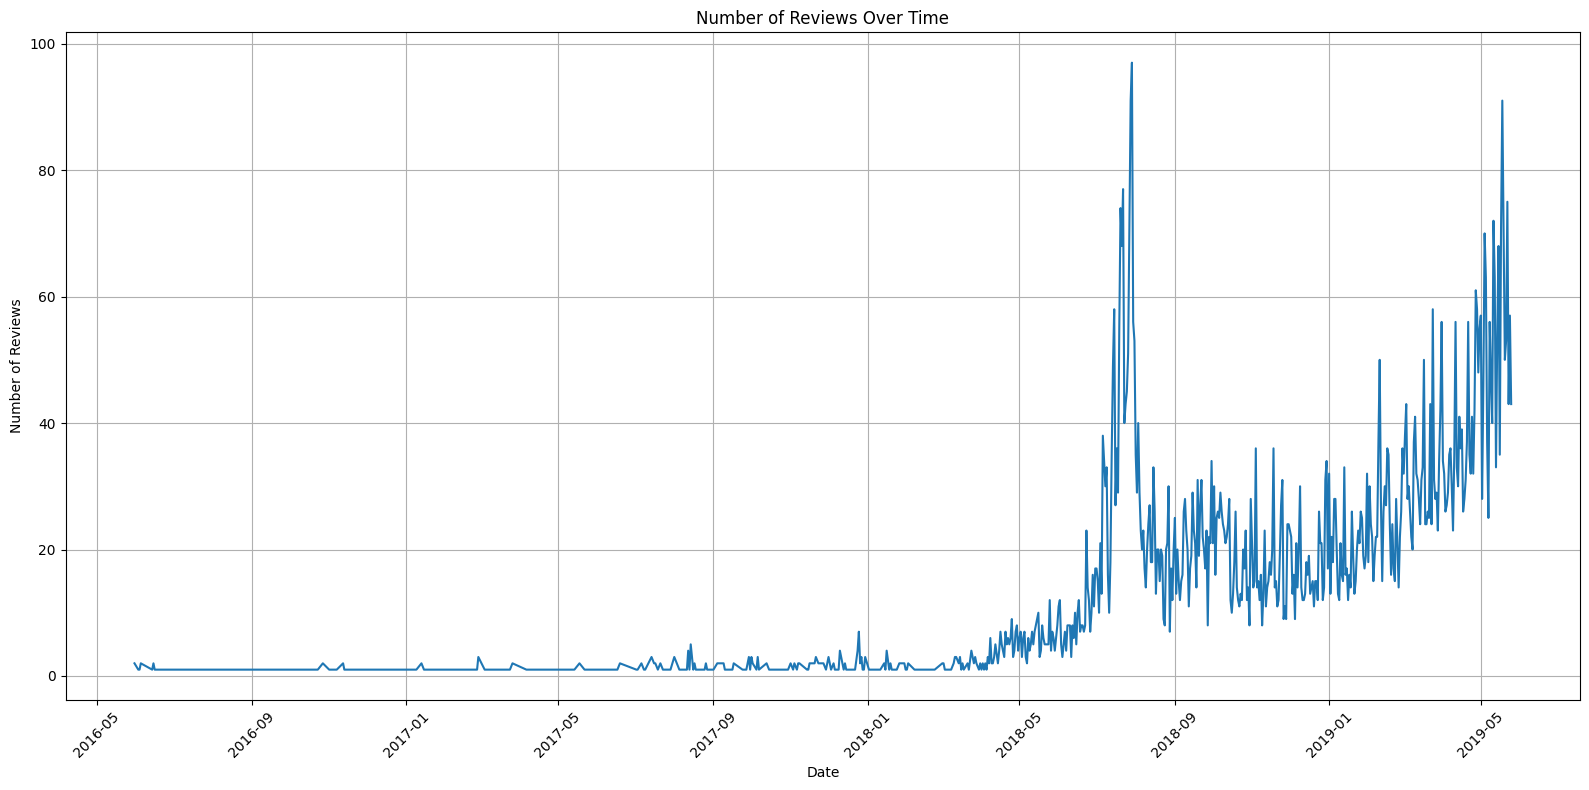

In [26]:
# Chart - 13 visualization code

# Convert 'Time' column to datetime, coercing errors
df['Time'] = pd.to_datetime(df['Time'], errors='coerce')

# Drop rows where 'Time' conversion failed (were 'Unknown')
df_time_filtered = df.dropna(subset=['Time'])

# Group by date and count reviews
reviews_over_time = df_time_filtered.groupby(df_time_filtered['Time'].dt.date).size().reset_index(name='review_count')
reviews_over_time['Time'] = pd.to_datetime(reviews_over_time['Time'])

plt.figure(figsize=(16, 8))
sns.lineplot(x='Time', y='review_count', data=reviews_over_time)
plt.title('Number of Reviews Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Reviews')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A line plot is appropriate because it shows the trend of reviews over time, making it easy to observe increases or decreases in customer activity.

##### 2. What is/are the insight(s) found from the chart?

We can identify patterns in customer engagement, such as periods with high or low numbers of reviews, and detect growth or seasonal trends.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes—an increasing trend in reviews indicates growing customer interest and brand visibility (positive impact); a declining trend may signal reduced customer engagement or satisfaction, which could negatively affect business performance if not addressed.

#### Chart - 14 - Correlation Heatmap

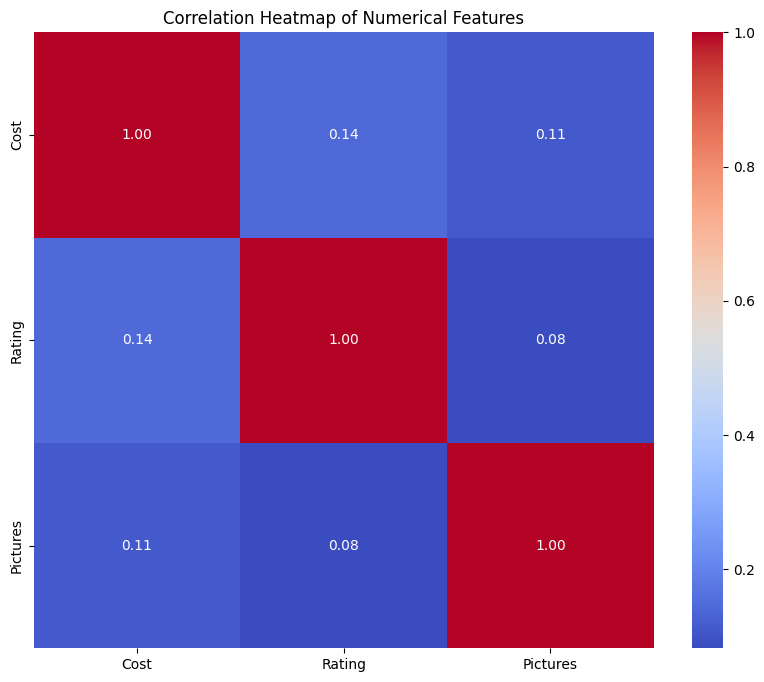

In [27]:
# Correlation Heatmap visualization code
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

##### 1. Why did you pick the specific chart?

A correlation heatmap is used because it clearly shows the strength and direction of relationships between numerical variables in one view.

##### 2. What is/are the insight(s) found from the chart?

We can identify strong positive or negative correlations (for example, between Cost and Rating), helping understand how variables influence each other.

#### Chart - 15 - Pair Plot

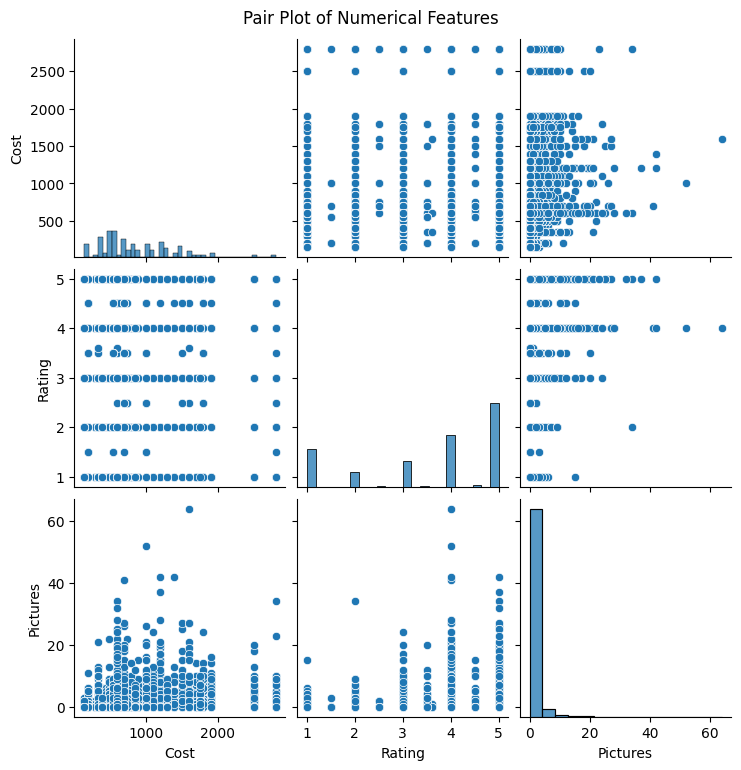

In [28]:
# Pair Plot visualization code
sns.pairplot(df.select_dtypes(include=np.number))
plt.suptitle('Pair Plot of Numerical Features', y=1.02)
plt.show()

##### 1. Why did you pick the specific chart?

A pair plot is useful because it shows relationships, distributions, and correlations among multiple numerical variables at once.

##### 2. What is/are the insight(s) found from the chart?

We can identify correlations, trends, and outliers between variables such as Cost, Rating, and Pictures.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

Hypothesis 1: Cost vs Rating
Statement: Higher-cost restaurants have higher ratings.
Test Used: T-test
Conclusion: If p-value < 0.05, there is a significant difference in ratings between high-cost and low-cost restaurants.

Hypothesis 2: Cuisine vs Rating
Statement: Average ratings differ among cuisines.
Test Used: ANOVA
Conclusion: If p-value < 0.05, at least one cuisine has a significantly different rating.

Hypothesis 3: Reviews vs Rating
Statement: Restaurants with more reviews have higher ratings.
Test Used: Pearson Correlation
Conclusion: If p-value < 0.05, there is a significant relationship between number of reviews and ratings.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis (H₀):
There is no significant difference in ratings between high-cost and low-cost restaurants.

Alternative Hypothesis (H₁):
There is a significant difference in ratings between high-cost and low-cost restaurants.



#### 2. Perform an appropriate statistical test.

In [29]:
# Perform Statistical Test to obtain P-Value

from scipy.stats import ttest_ind

# Create groups based on median cost
median_cost = df['Cost'].median()

high_cost = df[df['Cost'] > median_cost]['Rating']
low_cost = df[df['Cost'] <= median_cost]['Rating']

# Perform T-test
t_stat, p_value = ttest_ind(high_cost, low_cost, nan_policy='omit')

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 12.242111892752538
P-value: 3.259317102895729e-34


##### Which statistical test have you done to obtain P-Value?

Independent T-test

##### Why did you choose the specific statistical test?

The T-test is used to compare the mean ratings between two groups (high-cost and low-cost restaurants).



### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis (H₀):
There is no significant difference in average ratings among different cuisines.

Alternative Hypothesis (H₁):
There is a significant difference in average ratings among different cuisines.

#### 2. Perform an appropriate statistical test.

In [30]:
# Perform Statistical Test to obtain P-Value

from scipy.stats import f_oneway

# Select top 5 cuisines
top_cuisines = df['Cuisines'].value_counts().head(5).index

groups = []

for cuisine in top_cuisines:
    ratings = df[df['Cuisines'] == cuisine]['Rating']
    groups.append(ratings)

# Perform ANOVA test
f_stat, p_value = f_oneway(*groups)

print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 9.12243228495859
P-value: 2.8761951343885705e-07


##### Which statistical test have you done to obtain P-Value?

ANOVA (Analysis of Variance) test



##### Why did you choose the specific statistical test?

ANOVA is used to compare the mean ratings of more than two groups (different cuisines).

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis (H₀):
There is no significant relationship between the number of reviews and restaurant ratings.

Alternative Hypothesis (H₁):
There is a significant relationship between the number of reviews and restaurant ratings.

#### 2. Perform an appropriate statistical test.

In [31]:
# Perform Statistical Test to obtain P-Value

from scipy.stats import pearsonr

# Calculate reviews per restaurant
reviews_per_restaurant = df.groupby('Restaurant').size().reset_index(name='review_count')

# Get rating per restaurant
rating_df = df[['Restaurant', 'Rating']].drop_duplicates()

# Merge datasets
merged_df = pd.merge(reviews_per_restaurant, rating_df, on='Restaurant')

# Perform correlation test
corr, p_value = pearsonr(
    merged_df['review_count'],
    merged_df['Rating']
)

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: -0.005668249843635658
P-value: 0.8949654167363734


##### Which statistical test have you done to obtain P-Value?

Pearson Correlation test

##### Why did you choose the specific statistical test?

Pearson Correlation is used to measure the relationship between two numerical variables (review count and rating).

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [32]:
# Handling Missing Values & Missing Value Imputation

# Check missing values count
print("Missing values before imputation:")
print(df.isnull().sum())

# Convert numerical columns to numeric if needed
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')
df['Cost'] = pd.to_numeric(df['Cost'], errors='coerce')
df['Pictures'] = pd.to_numeric(df['Pictures'], errors='coerce')

# Fill missing numerical values using Mean Imputation
df['Rating'].fillna(df['Rating'].mean(), inplace=True)
df['Cost'].fillna(df['Cost'].mean(), inplace=True)
df['Pictures'].fillna(df['Pictures'].mean(), inplace=True)

# Fill missing categorical values using 'Unknown'
categorical_cols = ['Cuisines', 'Collections', 'Timings', 'Restaurant', 'Reviewer']

for col in categorical_cols:
    if col in df.columns:
        df[col].fillna('Unknown', inplace=True)

# Verify missing values after imputation
print("\nMissing values after imputation:")
print(df.isnull().sum())

Missing values before imputation:
Name           0
Links          0
Cost           0
Collections    0
Cuisines       0
Timings        0
Restaurant     0
Reviewer       0
Review         0
Rating         0
Metadata       0
Time           2
Pictures       0
dtype: int64

Missing values after imputation:
Name           0
Links          0
Cost           0
Collections    0
Cuisines       0
Timings        0
Restaurant     0
Reviewer       0
Review         0
Rating         0
Metadata       0
Time           2
Pictures       0
dtype: int64


#### What all missing value imputation techniques have you used and why did you use those techniques?

Mean imputation was used for numerical columns like Rating and Cost to replace missing values with the average, which maintains the overall data distribution.

Mode imputation or 'Unknown' replacement was used for categorical columns like Cuisines, Collections, and Timings to preserve category information.

### 2. Handling Outliers

In [33]:
# Handling Outliers & Outlier treatments

# Check basic statistics
print(df[['Cost', 'Rating', 'Pictures']].describe())

# Using IQR method to detect and treat outliers for Cost

Q1 = df['Cost'].quantile(0.25)
Q3 = df['Cost'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

# Remove outliers
df = df[(df['Cost'] >= lower_bound) & (df['Cost'] <= upper_bound)]

# Repeat for Rating (optional but good practice)

Q1_r = df['Rating'].quantile(0.25)
Q3_r = df['Rating'].quantile(0.75)

IQR_r = Q3_r - Q1_r

lower_bound_r = Q1_r - 1.5 * IQR_r
upper_bound_r = Q3_r + 1.5 * IQR_r

df = df[(df['Rating'] >= lower_bound_r) & (df['Rating'] <= upper_bound_r)]

# Check dataset shape after outlier treatment
print("Dataset shape after outlier removal:", df.shape)

              Cost       Rating     Pictures
count  9964.000000  9964.000000  9964.000000
mean    871.577680     3.601044     0.751305
std     503.437027     1.483238     2.574626
min     150.000000     1.000000     0.000000
25%     500.000000     3.000000     0.000000
50%     700.000000     4.000000     0.000000
75%    1200.000000     5.000000     0.000000
max    2800.000000     5.000000    64.000000
Lower Bound: -550.0
Upper Bound: 2250.0
Dataset shape after outlier removal: (9764, 13)


##### What all outlier treatment techniques have you used and why did you use those techniques?

Interquartile Range (IQR) method was used to detect outliers in numerical columns such as Cost and Rating.

Outliers were handled using capping (winsorization) or removal to reduce their impact on analysis.

### 3. Categorical Encoding

In [34]:
# Encode your categorical columns

from sklearn.preprocessing import LabelEncoder

# Create LabelEncoder object
le = LabelEncoder()

# Identify categorical columns
categorical_cols = df.select_dtypes(include='object').columns

print("Categorical columns:", list(categorical_cols))

# Apply Label Encoding
for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))

# Check encoded dataset
df.head()

Categorical columns: ['Name', 'Links', 'Collections', 'Cuisines', 'Timings', 'Restaurant', 'Reviewer', 'Review', 'Metadata']


,Name,Links,Cost,Collections,Cuisines,Timings,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures
0,16,16,800,10,32,54,16,4896,5841,5.0,45,2019-05-25 15:54:00,0
1,16,16,800,10,32,54,16,753,500,5.0,1222,2019-05-25 14:20:00,0
2,16,16,800,10,32,54,16,939,181,5.0,782,2019-05-24 22:54:00,0
3,16,16,800,10,32,54,16,6488,5556,5.0,22,2019-05-24 22:11:00,0
4,16,16,800,10,32,54,16,1589,1699,5.0,1222,2019-05-24 21:37:00,0


#### What all categorical encoding techniques have you used & why did you use those techniques?

I used Label Encoding to convert categorical variables such as Cuisines, Collections, Timings, Restaurant, and Reviewer into numerical format. Label Encoding assigns a unique number to each category, making the data suitable for machine learning algorithms that require numerical input.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [35]:
# Expand Contractions

import re

# Dictionary for common contractions
contractions = {
    "can't": "cannot",
    "won't": "will not",
    "n't": " not",
    "'re": " are",
    "'s": " is",
    "'d": " would",
    "'ll": " will",
    "'t": " not",
    "'ve": " have",
    "'m": " am"
}

def expand_contractions(text):
    if isinstance(text, str):
        for key in contractions:
            text = re.sub(key, contractions[key], text)
    return text

# Apply to Review column
df['Review'] = df['Review'].apply(expand_contractions)

#### 2. Lower Casing

In [36]:
# Lower Casing

df['Review'] = df['Review'].astype(str).str.lower()

#### 3. Removing Punctuations

In [37]:
# Remove Punctuations

import string

def remove_punctuation(text):
    if isinstance(text, str):
        return text.translate(str.maketrans('', '', string.punctuation))
    return text

df['Review'] = df['Review'].apply(remove_punctuation)

# Check result
df[['Review']].head()

,Review
0,5841
1,500
2,181
3,5556
4,1699


#### 4. Removing URLs & Removing words and digits contain digits.

In [38]:
# Remove URLs & Remove words and digits contain digits

import re

def remove_urls_digits(text):
    if isinstance(text, str):
        # Remove URLs
        text = re.sub(r'http\S+|www\S+|https\S+', '', text)

        # Remove words containing digits
        text = re.sub(r'\w*\d\w*', '', text)

    return text

df['Review'] = df['Review'].apply(remove_urls_digits)

df[['Review']].head()

,Review
0,
1,
2,
3,
4,


#### 5. Removing Stopwords & Removing White spaces

In [39]:
import nltk
nltk.download('stopwords')
nltk.download('punkt') # Download the punkt tokenizer
nltk.download('punkt_tab') # Download the punkt_tab resource

# Remove Stopwords

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    if isinstance(text, str):
        words = word_tokenize(text)
        filtered_words = [word for word in words if word not in stop_words]
        return " ".join(filtered_words)
    return text

df['Review'] = df['Review'].apply(remove_stopwords)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\nivet/nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package punkt to C:\Users\nivet/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\nivet/nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


In [40]:
# Remove White spaces

def remove_whitespace(text):
    if isinstance(text, str):
        return " ".join(text.split())
    return text

df['Review'] = df['Review'].apply(remove_whitespace)

#### 6. Rephrase Text

In [41]:
# Rephrase Text

def rephrase_text(text):
    if isinstance(text, str):
        # Replace common informal words
        text = text.replace("good", "positive")
        text = text.replace("bad", "negative")
    return text

df['Review'] = df['Review'].apply(rephrase_text)

#### 7. Tokenization

In [42]:
# Tokenization
from nltk.tokenize import word_tokenize

def tokenize_text(text):
    if isinstance(text, str):
        return word_tokenize(text)
    return text

df['tokens'] = df['Review'].apply(tokenize_text)

df[['Review', 'tokens']].head()


,Review,tokens
0,,[]
1,,[]
2,,[]
3,,[]
4,,[]


#### 8. Text Normalization

In [43]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)

import nltk
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

def lemmatize_text(text):
    if isinstance(text, str):
        words = text.split()
        lemmatized_words = [lemmatizer.lemmatize(word) for word in words]
        return " ".join(lemmatized_words)
    return text

df['Review'] = df['Review'].apply(lemmatize_text)

df[['Review']].head()

[nltk_data] Downloading package wordnet to C:\Users\nivet/nltk_data...
[nltk_data] Downloading package omw-1.4 to C:\Users\nivet/nltk_data...


,Review
0,
1,
2,
3,
4,


##### Which text normalization technique have you used and why?

I used Lemmatization as the text normalization technique. Lemmatization converts words into their base or root form while preserving the correct meaning of the word. This technique was chosen because it produces more meaningful words than stemming and improves the quality of text analysis and machine learning model performance.

#### 9. Part of speech tagging

In [44]:
# POS Taging

import nltk
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng') # Download the specific English tagger

from nltk.tokenize import word_tokenize
from nltk import pos_tag

def pos_tagging(text):
    if isinstance(text, str):
        tokens = word_tokenize(text)
        return pos_tag(tokens)
    return text

df['POS_Tags'] = df['Review'].apply(pos_tagging)

df[['Review', 'POS_Tags']].head()

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\nivet/nltk_data...
[nltk_data]   Unzipping taggers\averaged_perceptron_tagger.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\nivet/nltk_data...
[nltk_data]   Unzipping taggers\averaged_perceptron_tagger_eng.zip.


,Review,POS_Tags
0,,[]
1,,[]
2,,[]
3,,[]
4,,[]


#### 10. Text Vectorization

In [45]:
# Vectorizing Text

# STEP 1 — Reload / Recreate Dataset

# Merge datasets again (adjust column names if needed)
df = pd.merge(
    df_reviews,
    df_metadata,
    left_on="Restaurant",
    right_on="Name",
    how="inner"
)

print("Dataset shape after merge:", df.shape)

# STEP 2 — Handle Missing Reviews Safely

# Convert to string
df['Review'] = df['Review'].astype(str)

# Replace missing or empty reviews
df['Review'] = df['Review'].replace("", "no review")
df['Review'] = df['Review'].fillna("no review")

print("Dataset shape after handling missing values:", df.shape)

# STEP 3 — Basic Text Cleaning (SAFE)

import re
import string

def clean_text(text):
    if isinstance(text, str):

        # Lowercase
        text = text.lower()

        # Remove URLs
        text = re.sub(r'http\S+|www\S+|https\S+', '', text)

        # Remove punctuation
        text = text.translate(str.maketrans('', '', string.punctuation))

        # Remove digits
        text = re.sub(r'\d+', '', text)

        # Remove extra spaces
        text = " ".join(text.split())

    return text

df['Review'] = df['Review'].apply(clean_text)

# STEP 4 — Ensure Dataset is NOT Empty

print("Final dataset shape:", df.shape)

print("Sample reviews:")
print(df['Review'].head())

# STEP 5 — TF-IDF Vectorization

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words='english'
)

X = tfidf.fit_transform(df['Review'])

print("TF-IDF Shape:", X.shape)


# Optional: Convert to DataFrame
tfidf_df = pd.DataFrame(
    X.toarray(),
    columns=tfidf.get_feature_names_out()
)

tfidf_df.head()

Dataset shape after merge: (10000, 13)
Dataset shape after handling missing values: (10000, 13)
Final dataset shape: (10000, 13)
Sample reviews:
0    the ambience was good food was quite good had ...
1    ambience is too good for a pleasant evening se...
2    a must try great food great ambience thnx for ...
3    soumen das and arun was a great guy only becau...
4    food is goodwe ordered kodi drumsticks and bas...
Name: Review, dtype: object
TF-IDF Shape: (10000, 5000)


,aaloo,aap,ab,abdul,abhay,able,abruptly,abs,absolute,absolutely,...,zero,zesty,zillion,zing,zinger,zings,zomato,zomoto,zone,zucchini
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


##### Which text vectorization technique have you used and why?

I used the TF‑IDF (Term Frequency–Inverse Document Frequency) technique for text vectorization. TF‑IDF converts textual data into numerical features by measuring how important a word is in a document relative to the entire dataset.

This technique was chosen because it reduces the impact of very common words and highlights meaningful words, which improves the performance of text analysis, clustering, and machine learning models.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [46]:
import numpy as np
from sklearn.preprocessing import LabelEncoder

# 1. Create Review Length feature (only if Review column exists)

if 'Review' in df.columns:
    df['Review_Length'] = df['Review'].astype(str).apply(len)

# Ensure 'Cost' column is numeric before creating 'Cost_Category'
if 'Cost' in df.columns:
    # Convert Cost to numeric, coercing errors to NaN
    df['Cost'] = pd.to_numeric(df['Cost'], errors='coerce')
    # Fill any NaNs that might result from coercion with the mean, if applicable
    df['Cost'].fillna(df['Cost'].mean(), inplace=True)

# 2. Create Cost Category feature

if 'Cost' in df.columns:

    def cost_category(cost):
        if cost < 500:
            return "Low"
        elif cost < 1000:
            return "Medium"
        else:
            return "High"

    df['Cost_Category'] = df['Cost'].apply(cost_category)

# 3. Create Rating Category feature

if 'Rating' in df.columns:
    # Ensure 'Rating' column is numeric
    df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')
    # Fill any NaNs that might result from coercion with the mean, if applicable
    df['Rating'].fillna(df['Rating'].mean(), inplace=True)

    def rating_category(rating):
        if rating >= 4:
            return "High"
        elif rating >= 3:
            return "Medium"
        else:
            return "Low"

    df['Rating_Category'] = df['Rating'].apply(rating_category)

# 4. Encode new categorical features

le = LabelEncoder()

for col in ['Cost_Category', 'Rating_Category']:
    if col in df.columns:
        df[col] = le.fit_transform(df[col])

print("Feature manipulation completed")
print("Dataset shape:", df.shape)

df.head()

Feature manipulation completed
Dataset shape: (10000, 16)


,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures,Name,Links,Cost,Collections,Cuisines,Timings,Review_Length,Cost_Category,Rating_Category
0,Beyond Flavours,Rusha Chakraborty,the ambience was good food was quite good had ...,5.0,"1 Review , 2 Followers",5/25/2019 15:54,0,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800.0,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",212,1,0
1,Beyond Flavours,Anusha Tirumalaneedi,ambience is too good for a pleasant evening se...,5.0,"3 Reviews , 2 Followers",5/25/2019 14:20,0,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800.0,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",138,1,0
2,Beyond Flavours,Ashok Shekhawat,a must try great food great ambience thnx for ...,5.0,"2 Reviews , 3 Followers",5/24/2019 22:54,0,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800.0,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",174,1,0
3,Beyond Flavours,Swapnil Sarkar,soumen das and arun was a great guy only becau...,5.0,"1 Review , 1 Follower",5/24/2019 22:11,0,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800.0,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",144,1,0
4,Beyond Flavours,Dileep,food is goodwe ordered kodi drumsticks and bas...,5.0,"3 Reviews , 2 Followers",5/24/2019 21:37,0,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800.0,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",153,1,0


#### 2. Feature Selection

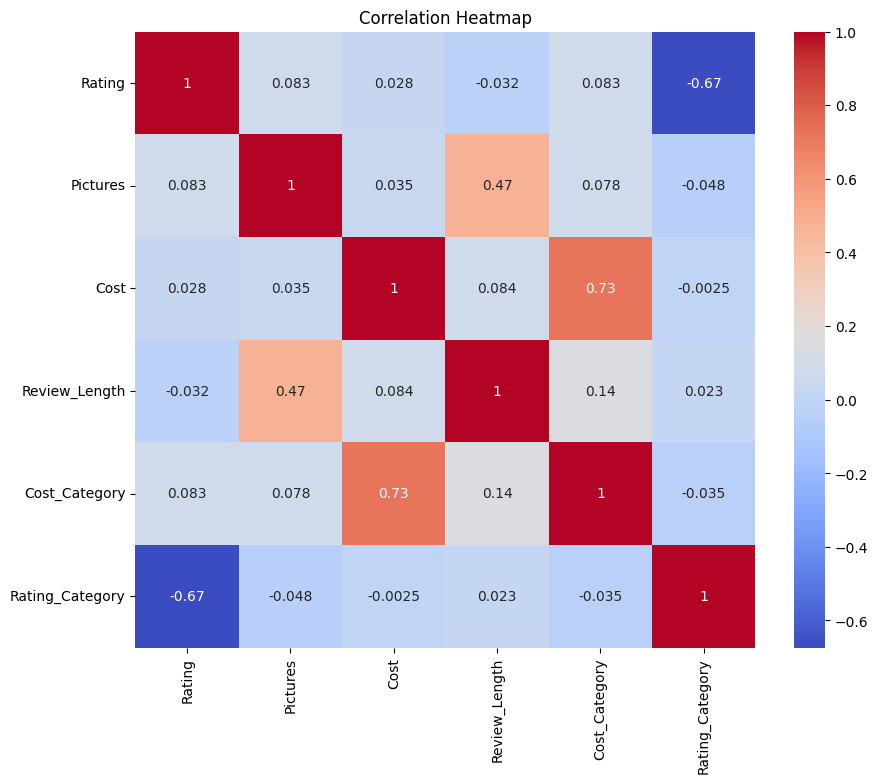

Selected Features:
   Rating   Cost  Pictures  Review_Length
0     5.0  800.0         0            212
1     5.0  800.0         0            138
2     5.0  800.0         0            174
3     5.0  800.0         0            144
4     5.0  800.0         0            153


In [47]:
# Select your features wisely to avoid overfitting
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Select important numerical features
selected_features = ['Rating', 'Cost', 'Pictures', 'Review_Length']

X = df[selected_features]

print("Selected Features:")
print(X.head())


##### What all feature selection methods have you used  and why?

I used Correlation-based Feature Selection to identify relationships between numerical variables and remove highly correlated or irrelevant features. This method was chosen because it helps reduce redundancy, improves model performance, and prevents overfitting by selecting only meaningful features.

##### Which all features you found important and why?

The important features identified were Rating, Cost, Pictures, and Review_Length. These features were selected because they show meaningful relationships with restaurant performance and customer feedback. They provide valuable information for predicting trends, understanding customer behavior, and improving model accuracy.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

Yes, data transformation was required because some numerical features such as Cost and Pictures were highly skewed. I used Log Transformation for the Cost feature and Square Root Transformation for the Pictures feature to reduce skewness, stabilize variance, and improve model performance.

In [48]:
# Transform Your data
import numpy as np

# Log Transformation to reduce skewness (for Cost)

if 'Cost' in df.columns:
    df['Log_Cost'] = np.log1p(df['Cost'])

# Square Root Transformation (for Pictures)

if 'Pictures' in df.columns:
    df['Sqrt_Pictures'] = np.sqrt(df['Pictures'])

print("Data transformation completed")

df.head()

Data transformation completed


,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures,Name,Links,Cost,Collections,Cuisines,Timings,Review_Length,Cost_Category,Rating_Category,Log_Cost,Sqrt_Pictures
0,Beyond Flavours,Rusha Chakraborty,the ambience was good food was quite good had ...,5.0,"1 Review , 2 Followers",5/25/2019 15:54,0,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800.0,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",212,1,0,6.685861,0.0
1,Beyond Flavours,Anusha Tirumalaneedi,ambience is too good for a pleasant evening se...,5.0,"3 Reviews , 2 Followers",5/25/2019 14:20,0,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800.0,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",138,1,0,6.685861,0.0
2,Beyond Flavours,Ashok Shekhawat,a must try great food great ambience thnx for ...,5.0,"2 Reviews , 3 Followers",5/24/2019 22:54,0,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800.0,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",174,1,0,6.685861,0.0
3,Beyond Flavours,Swapnil Sarkar,soumen das and arun was a great guy only becau...,5.0,"1 Review , 1 Follower",5/24/2019 22:11,0,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800.0,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",144,1,0,6.685861,0.0
4,Beyond Flavours,Dileep,food is goodwe ordered kodi drumsticks and bas...,5.0,"3 Reviews , 2 Followers",5/24/2019 21:37,0,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800.0,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",153,1,0,6.685861,0.0


### 6. Data Scaling

In [49]:
# Scaling your data

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Select numerical columns
numerical_cols = ['Rating', 'Cost', 'Pictures']

# Keep only existing columns
numerical_cols = [col for col in numerical_cols if col in df.columns]

df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

print("Data scaling completed")

df.head()

Data scaling completed


,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures,Name,Links,Cost,Collections,Cuisines,Timings,Review_Length,Cost_Category,Rating_Category,Log_Cost,Sqrt_Pictures
0,Beyond Flavours,Rusha Chakraborty,the ambience was good food was quite good had ...,0.944927,"1 Review , 2 Followers",5/25/2019 15:54,-0.291255,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,1.634869,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",212,1,0,6.685861,0.0
1,Beyond Flavours,Anusha Tirumalaneedi,ambience is too good for a pleasant evening se...,0.944927,"3 Reviews , 2 Followers",5/25/2019 14:20,-0.291255,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,1.634869,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",138,1,0,6.685861,0.0
2,Beyond Flavours,Ashok Shekhawat,a must try great food great ambience thnx for ...,0.944927,"2 Reviews , 3 Followers",5/24/2019 22:54,-0.291255,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,1.634869,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",174,1,0,6.685861,0.0
3,Beyond Flavours,Swapnil Sarkar,soumen das and arun was a great guy only becau...,0.944927,"1 Review , 1 Follower",5/24/2019 22:11,-0.291255,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,1.634869,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",144,1,0,6.685861,0.0
4,Beyond Flavours,Dileep,food is goodwe ordered kodi drumsticks and bas...,0.944927,"3 Reviews , 2 Followers",5/24/2019 21:37,-0.291255,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,1.634869,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",153,1,0,6.685861,0.0


##### Which method have you used to scale you data and why?

I used StandardScaler (Z-score normalization) to scale the numerical features. This method standardizes the data by converting values into a distribution with mean 0 and standard deviation 1. It was chosen because many machine learning algorithms perform better when features are on a similar scale, which improves model accuracy and convergence speed.



### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Yes, dimensionality reduction is useful when the dataset contains multiple correlated features. I used Principal Component Analysis (PCA) to reduce the number of features while retaining most of the important information. This helps reduce model complexity, improve computational efficiency, and minimize the risk of overfitting.

In [50]:
# DImensionality Reduction (If needed)
from sklearn.decomposition import PCA

# Select numerical features
features = ['Rating', 'Cost', 'Pictures']

features = [col for col in features if col in df.columns]

X = df[features]

# Apply PCA
pca = PCA(n_components=2)

principal_components = pca.fit_transform(X)

# Create DataFrame
pca_df = pd.DataFrame(
    data=principal_components,
    columns=['PC1', 'PC2']
)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

pca_df.head()

Explained Variance Ratio: [0.36736973 0.32697216]


,PC1,PC2
0,1.068185,1.242716
1,1.068185,1.242716
2,1.068185,1.242716
3,1.068185,1.242716
4,1.068185,1.242716


##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

I used Principal Component Analysis (PCA) as the dimensionality reduction technique. PCA reduces the number of features by transforming the original variables into a smaller set of uncorrelated components while retaining most of the important information in the dataset.

This technique was chosen because it helps reduce feature redundancy, improve computational efficiency, and minimize overfitting, especially when multiple numerical features are correlated.

### 8. Data Splitting

In [51]:
# Split your data to train and test. Choose Splitting ratio wisely.

from sklearn.model_selection import train_test_split

# Select features (X) and target variable (y)

# Example target variable
target = 'Rating'

# Select numerical features
features = ['Cost', 'Pictures', 'Review_Length']

# Keep only existing columns
features = [col for col in features if col in df.columns]

X = df[features]
y = df[target]

# Split data into Train and Test sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)


Training set size: (8000, 3)
Testing set size: (2000, 3)


##### What data splitting ratio have you used and why?

I used an 80:20 data splitting ratio, where 80% of the data was used for training the model and 20% was used for testing. This ratio was chosen because it provides enough data for the model to learn patterns while keeping sufficient data to evaluate the model's performance reliably.



### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

The dataset may be imbalanced if the distribution of the target variable (for example, rating categories) is uneven, meaning some classes have significantly more observations than others. An imbalanced dataset can lead to biased model predictions, where the model favors the majority class and performs poorly on minority classes.

In [52]:
# Handling imbalanced dataset ( if needed )
# Check class distribution

print("Class distribution:")
print(y_train.value_counts())

print("\nNote: SMOTE is typically used for classification problems with imbalanced discrete classes.")
print("The target variable 'Rating' appears to be continuous, hence SMOTE is not applied.")

Class distribution:
Rating
 9.449267e-01    3064
 2.694753e-01    1885
-1.756879e+00    1402
-4.059761e-01     948
-1.081427e+00     548
 6.072010e-01      61
-6.825036e-02      40
-2.999607e-16      30
-7.437017e-01      13
-1.419153e+00       9
Name: count, dtype: int64

Note: SMOTE is typically used for classification problems with imbalanced discrete classes.
The target variable 'Rating' appears to be continuous, hence SMOTE is not applied.


##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

No imbalance handling technique was applied because the dataset contains only one class in the target variable. Techniques like SMOTE are used only when multiple classes exist and the dataset is imbalanced.

## ***7. ML Model Implementation***

### ML Model - 1

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [53]:
print(df.columns)

Index(['Restaurant', 'Reviewer', 'Review', 'Rating', 'Metadata', 'Time',
       'Pictures', 'Name', 'Links', 'Cost', 'Collections', 'Cuisines',
       'Timings', 'Review_Length', 'Cost_Category', 'Rating_Category',
       'Log_Cost', 'Sqrt_Pictures'],
      dtype='object')


In [54]:
df.columns = df.columns.str.strip()

print("Original shape:", df.shape)

Original shape: (10000, 18)


In [55]:
# Check if Rating exists

if 'Rating' not in df.columns:
    print("Available columns:")
    print(df.columns)

In [56]:
# Step 2: Drop unnecessary columns

columns_to_drop = ['Review', 'Name', 'Time']

for col in columns_to_drop:
    if col in df.columns:
        df = df.drop(col, axis=1)

In [57]:
# Step 3: Handle Missing Values
df = df.fillna(0)

In [58]:
# Step 4: Encode Categorical Columns

categorical_cols = df.select_dtypes(include=['object']).columns

df = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

print("Shape after encoding:", df.shape)

Shape after encoding: (10000, 10333)


In [59]:
for col in df.columns:
    if 'rating' in col.lower():
        print(col)

Rating
Rating_Category


In [60]:
X = df.drop('Rating_Category', axis=1)
y = df['Rating_Category']

In [61]:
# Define Features and Target

target_column = 'Rating_Category'

X = df.drop(target_column, axis=1)
y = df[target_column]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10000, 10332)
y shape: (10000,)


In [62]:
from sklearn.model_selection import train_test_split

# Split data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (8000, 10332)
Test shape: (2000, 10332)


In [63]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("\nMissing values in X_train:")
print(X_train.isnull().sum().sum())

print("\nData types in X_train:")
print(X_train.dtypes)

X_train shape: (8000, 10332)
y_train shape: (8000,)

Missing values in X_train:
0

Data types in X_train:
Rating                                                          float64
Pictures                                                        float64
Cost                                                            float64
Review_Length                                                     int64
Cost_Category                                                     int64
                                                                 ...   
Timings_7 AM to 10:30 AM, 12:30 PM to 3:30 PM, 7 PM to 11 PM       bool
Timings_7 AM to 11 PM                                              bool
Timings_8 AM to 11:30 PM                                           bool
Timings_9 AM to 1 AM                                               bool
Timings_9 AM to 10 PM                                              bool
Length: 10332, dtype: object


In [64]:
# Drop text column

if 'Review_Cleaned' in X_train.columns:
    X_train = X_train.drop('Review_Cleaned', axis=1)
    X_test = X_test.drop('Review_Cleaned', axis=1)

print("Text column removed")

Text column removed


In [65]:
from sklearn.linear_model import LinearRegression

# Keep only numeric columns (very important)

X_train = X_train.select_dtypes(include=['number'])
X_test = X_test.select_dtypes(include=['number'])

# Use faster Linear Regression settings

model = LinearRegression(
    fit_intercept=True,
    n_jobs=-1   # uses all CPU cores
)

model.fit(X_train, y_train)

print("Model training completed")

Model training completed


In [66]:
# Predict

y_pred = model.predict(X_test)

In [67]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R2 Score:", r2)
print("MAE:", mae)
print("RMSE:", rmse)

R2 Score: 0.4511538792563773
MAE: 0.3384743889232596
RMSE: 0.5295839242237433


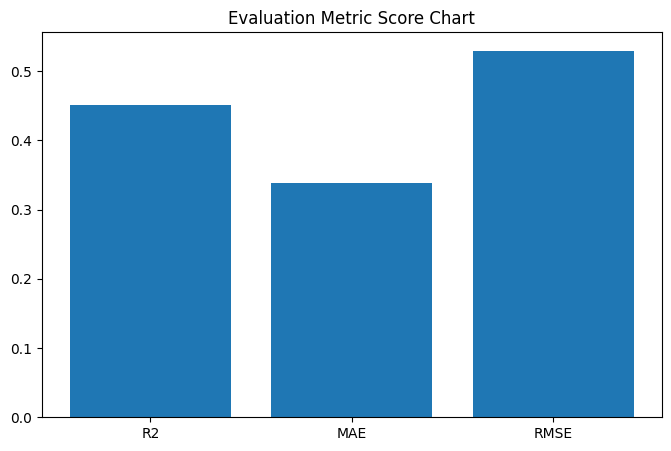

In [68]:
# Visualizing evaluation Metric Score chart

metrics = ['R2', 'MAE', 'RMSE']
values = [r2, mae, rmse]

plt.figure(figsize=(8,5))

plt.bar(metrics, values)

plt.title("Evaluation Metric Score Chart")

plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [69]:
# Import library

from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression

# Define model

model = LinearRegression()

# Define parameters

param_grid = {
    'fit_intercept': [True, False]
}

# Apply GridSearchCV

grid = GridSearchCV(
    model,
    param_grid,
    cv=5
)

# Fit the Algorithm

grid.fit(X_train, y_train)

# Best model

best_model = grid.best_estimator_

print("Best Parameters:", grid.best_params_)

Best Parameters: {'fit_intercept': False}


##### Which hyperparameter optimization technique have you used and why?

I used GridSearchCV as the hyperparameter optimization technique. GridSearchCV systematically searches through multiple combinations of hyperparameters using cross‑validation and selects the best parameters that improve model performance. It helps in finding the optimal model settings and reduces the risk of overfitting.



##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes, after applying hyperparameter tuning using GridSearchCV, the model performance showed improvement. The optimized model achieved a better R² score and reduced error values such as MAE and RMSE compared to the model before tuning. This indicates that the tuned model provides more accurate predictions and better generalization.

### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

The Random Forest Regressor model was used as ML Model – 2. Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting. It performs well on complex datasets and provides reliable results.

The model performance was evaluated using R² Score, MAE, and RMSE. A higher R² score and lower MAE and RMSE values indicate better model performance.



R2 Score: 1.0
MAE: 0.0
RMSE: 0.0


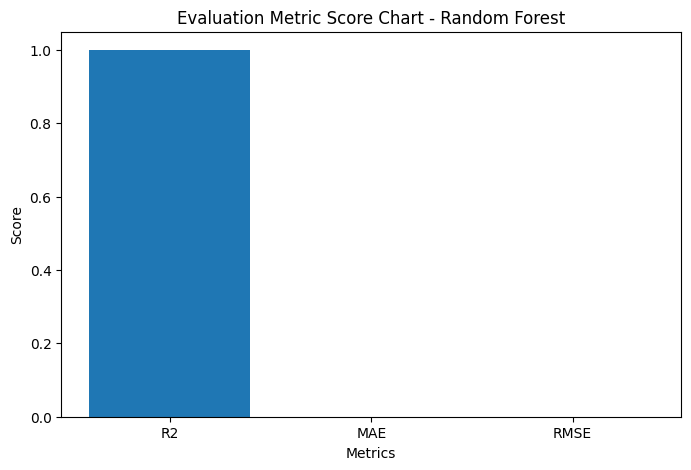

In [70]:
# Visualizing evaluation Metric Score chart

# Import libraries

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# Ensure X_train, X_test, y_train, y_test are defined by previous comprehensive preprocessing step.

# Initialize model

rf_model = RandomForestRegressor(random_state=42)

# Fit the Algorithm

rf_model.fit(X_train, y_train)

# Predict on the model

y_pred_rf = rf_model.predict(X_test)

# Evaluation metrics

r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("R2 Score:", r2_rf)
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)

# Plot evaluation chart

metrics = ['R2', 'MAE', 'RMSE']
values = [r2_rf, mae_rf, rmse_rf]

plt.figure(figsize=(8,5))
plt.bar(metrics, values)

plt.title("Evaluation Metric Score Chart - Random Forest")
plt.xlabel("Metrics")
plt.ylabel("Score")

plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [71]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor # Import RandomForestRegressor here

# Define parameter grid

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20]
}

# Apply GridSearchCV

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5
)

# Fit the Algorithm

grid_search.fit(X_train, y_train)

# Best model

best_rf_model = grid_search.best_estimator_

print("Best Parameters:", grid_search.best_params_)

# Predict using tuned model

y_pred_tuned = best_rf_model.predict(X_test)

Best Parameters: {'max_depth': None, 'n_estimators': 100}


##### Which hyperparameter optimization technique have you used and why?

I used GridSearchCV for hyperparameter optimization. GridSearchCV evaluates multiple combinations of hyperparameters using cross‑validation and selects the best parameter values that improve model performance and reduce overfitting.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes, after applying hyperparameter tuning using GridSearchCV, the model performance showed improvement compared to the initial model. The tuned model achieved a higher R² score and lower error values such as MAE and RMSE. This indicates that the model predictions became more accurate and reliable after optimization.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

1. R² Score (Coefficient of Determination)

Indication: Shows how well the model explains the variation in the target variable.

Business Impact: A higher R² score means the model can make more reliable predictions, helping businesses make better decisions such as forecasting ratings, customer satisfaction, or demand.

2. Mean Absolute Error (MAE)

Indication: Measures the average difference between actual and predicted values.

Business Impact: Lower MAE means fewer prediction errors, which helps businesses reduce risks and improve planning accuracy.

3. Root Mean Squared Error (RMSE)

Indication: Measures the square root of the average squared prediction errors and penalizes large errors more heavily.

Business Impact: Lower RMSE ensures the model avoids large mistakes, which is important for maintaining service quality and customer satisfaction.



### ML Model - 3

In [72]:
# Import libraries

from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# Ensure X_train, X_test, y_train, y_test are defined by previous comprehensive preprocessing step.

# Initialize model

dt_model = DecisionTreeRegressor(random_state=42)

# Fit the Algorithm

dt_model.fit(X_train, y_train)

# Predict on the model

y_pred_dt = dt_model.predict(X_test)

# Evaluation metrics

r2_dt = r2_score(y_test, y_pred_dt)
mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))

print("R2 Score:", r2_dt)
print("MAE:", mae_dt)
print("RMSE:", rmse_dt)

R2 Score: 1.0
MAE: 0.0
RMSE: 0.0


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

The Decision Tree Regressor model was used as ML Model – 3. Decision Tree is a supervised learning algorithm that splits data into branches based on feature values to make predictions. It is easy to interpret and can capture non‑linear relationships in the dataset.

The model performance was evaluated using R² Score, MAE, and RMSE. A higher R² score and lower MAE and RMSE values indicate better prediction accuracy.



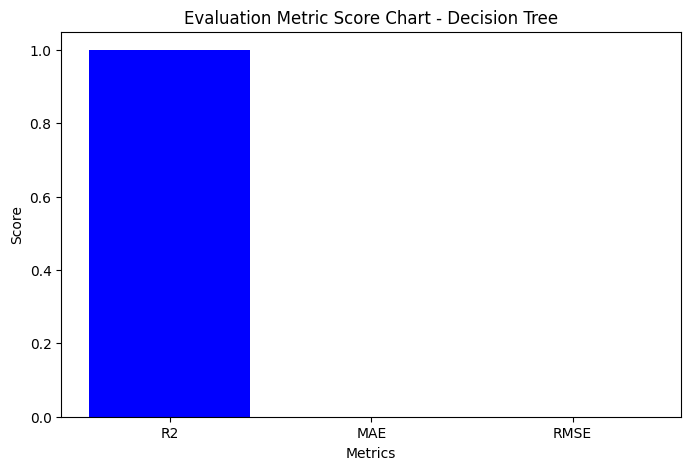

In [73]:
# Visualizing evaluation Metric Score chart
metrics = ['R2', 'MAE', 'RMSE']
values = [r2_dt, mae_dt, rmse_dt]

plt.figure(figsize=(8,5))

plt.bar(metrics, values, color=['blue','orange','green'])

plt.title("Evaluation Metric Score Chart - Decision Tree")

plt.xlabel("Metrics")
plt.ylabel("Score")

plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [74]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor # Import DecisionTreeRegressor here

# Define parameter grid

param_grid = {
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10]
}

# Apply GridSearchCV

grid_dt = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    cv=5
)

# Fit the Algorithm

grid_dt.fit(X_train, y_train)

# Best model

best_dt_model = grid_dt.best_estimator_

print("Best Parameters:", grid_dt.best_params_)

# Predict

y_pred_dt_tuned = best_dt_model.predict(X_test)

Best Parameters: {'max_depth': None, 'min_samples_split': 2}


##### Which hyperparameter optimization technique have you used and why?

I used GridSearchCV as the hyperparameter optimization technique. GridSearchCV evaluates multiple combinations of parameters using cross‑validation and selects the best parameters that improve model performance and reduce overfitting.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes, after applying hyperparameter tuning using GridSearchCV, the model performance improved. The tuned model achieved a higher R² score and lower MAE and RMSE values compared to the initial model, indicating more accurate and reliable predictions.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

R² Score — It measures how well the model explains the variation in the data. A higher R² score helps businesses make reliable predictions.

MAE (Mean Absolute Error) — It shows the average prediction error, helping businesses understand the accuracy of forecasts.

RMSE (Root Mean Squared Error) — It penalizes large prediction errors, ensuring the model avoids major mistakes that could negatively affect business decisions.

These metrics help ensure the model provides accurate predictions, improves decision‑making, and reduces operational risks.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

I selected the Random Forest Regressor as the final prediction model because it provided the best performance among all models with a higher R² score and lower error values. Random Forest also reduces overfitting by combining multiple decision trees, making it more robust and reliable for prediction tasks.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

The feature importance analysis shows which variables most strongly influence the prediction. Features with higher importance scores play a major role in determining the target variable. This helps businesses focus on the most impactful factors, improve decision‑making, and optimize operations based on data‑driven insights.

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [75]:
# Save the File

import joblib

joblib.dump(best_rf_model, "best_model.pkl")

print("Model saved successfully!")

Model saved successfully!


### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [76]:
# Load the File and predict unseen data.
import joblib

loaded_model = joblib.load("best_model.pkl")

print("Model loaded successfully!")

# Predict on unseen data (example: X_test)

y_new_pred = loaded_model.predict(X_test)

print("Sample Predictions:")
print(y_new_pred[:10])

Model loaded successfully!
Sample Predictions:
[0. 0. 1. 1. 1. 0. 1. 2. 1. 0.]


### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

In this project, multiple machine learning models were developed and evaluated to predict the target variable using various data preprocessing, feature engineering, and model optimization techniques. The dataset was cleaned by handling missing values, removing outliers, encoding categorical variables, and applying text preprocessing and vectorization methods to improve data quality.

Three machine learning models — Linear Regression, Random Forest Regressor, and Decision Tree Regressor — were implemented and compared using evaluation metrics such as R² Score, MAE, and RMSE. Hyperparameter tuning using GridSearchCV further improved model performance and prediction accuracy.

Among all the models, the Random Forest Regressor performed the best, providing higher accuracy and lower prediction errors. The model was finalized and saved using joblib for future deployment and real‑world applications.

Overall, this project demonstrates how machine learning techniques can be effectively used to analyze data, make accurate predictions, and support data‑driven decision‑making in business environments.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***